In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LassoCV
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
import matplotlib.dates as mdates

In [2]:
# ALC
# read in the data from pre-processing steps
train_data = pd.read_csv("../data/processed/training_data_v2.csv")
test_data = pd.read_csv("../data/processed/test_data_v2.csv")

In [3]:
# ALC
# dropping everything we already used PCA to reduce
for feature in ['num_alerts', 'alert_effect_delay', 'alert_effect_shuttle',
                'num_slow_zones', 'total_track_pct', 'total_miles_affected',
               'num_alerts_log', 'alert_effect_delay_log', 
               'alert_effect_shuttle_log', 'num_slow_zones_sqrt',
               # one of each of our one-hot encoded vars
               'line_blue', 'month_January', 'service_quality_cluster_0', 
                'day_of_week_Sunday']:
    train_data = train_data.drop(feature, axis = 1)
    test_data = test_data.drop(feature, axis = 1)

In [4]:
# same as for k means clustering above let's fill 
# missing lag variables with mean
numeric_cols = train_data.select_dtypes(include=['number']).columns
train_data[numeric_cols] = train_data[numeric_cols].fillna(train_data[numeric_cols].mean())
y_train = train_data['est_ridership']
X_train = train_data.drop(columns=['est_ridership'])
# we are looking for numeric variables
X_train['service_date'] = X_train['service_date'].apply(lambda x: pd.to_datetime(x).timestamp())
# outcome var
y_test = test_data['est_ridership']
X_test = test_data.drop(columns=['est_ridership'])
# this needs to be numeric too or else we have trouble
X_test['service_date'] = X_test['service_date'].apply(lambda x: pd.to_datetime(x).timestamp())

In [5]:
# ALC
# scale and center all variables, fit on train and apply to train and test
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

In [6]:
# ALC
tscv = TimeSeriesSplit()
# max_iter a little higher to solve issue with duality gap
lasso_cv = LassoCV(cv = tscv, 
                   random_state = 42, max_iter = 100000)
lasso_cv.fit(X_train_scaled, y_train)
print(lasso_cv.alpha_)

y_pred = lasso_cv.predict(X_test_scaled)
y_train_pred = lasso_cv.predict(X_train_scaled)

30.276183315419665


In [7]:
# ALC
# TRAINING MSE
mse = mean_squared_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)
rmse = root_mean_squared_error(y_train, y_train_pred)
print(f"Training MSE: {mse:.4f}, R2: {r2:.4f}, RMSE: {rmse}")

Training MSE: 85323026.3394, R2: 0.8404, RMSE: 9237.046407773487


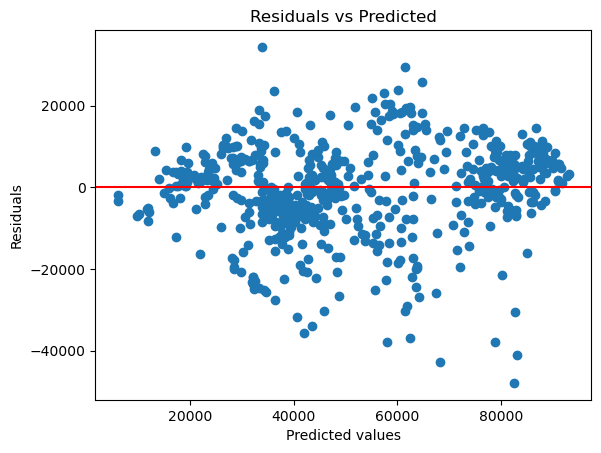

In [8]:
# ALC
# plot residuals
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y = 0, color = 'red')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

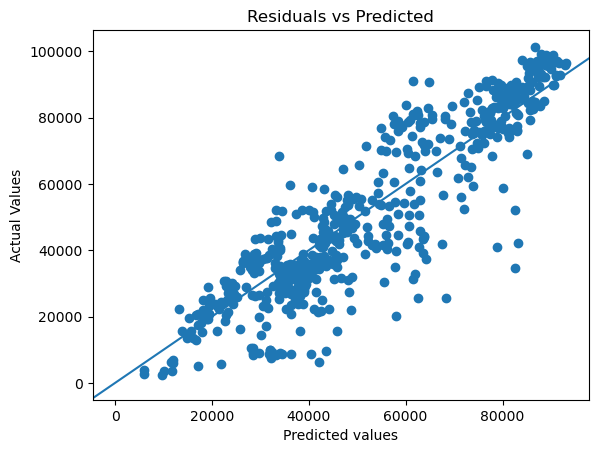

In [9]:
# ALC
plt.scatter(y_pred, y_test)
plt.axline((0, 0), slope=1)
plt.xlabel('Predicted values')
plt.ylabel('Actual Values')
plt.title('Residuals vs Predicted')
plt.show()

In [10]:
# ALC
# get an idea of test MSE and r^2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}, R2: {r2:.4f}, RMSE: {rmse}")

Test MSE: 124995994.1522, R2: 0.8060, RMSE: 11180.160739105911


In [11]:
# ALC
# get coefficients
coefs = lasso_cv.coef_

# match coefficients with features
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': coefs
})

# which were not selected
zero_coef_features = coef_df[coef_df['coefficient'] == 0]['feature'].tolist()
nonzero_coef_features = coef_df[coef_df['coefficient'] != 0]['feature'].tolist()

print("Features shrunk to zero (est_ridership):")
print(zero_coef_features)
print("Features with nonzero coefficients")
print(nonzero_coef_features)

coef_df.sort_values('coefficient', ascending = False)

Features shrunk to zero (est_ridership):
['otp_score', 'total_track_pct_log', 'line_orange', 'day_of_week_Thursday', 'month_June', 'slow_zones_7day_avg', 'slow_zones_x_blue', 'slow_zones_x_green', 'slow_zones_x_red', 'infrastructure_stress_pc2']
Features with nonzero coefficients
['service_date', 'has_special_event', 'line_green', 'line_red', 'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'month_April', 'month_August', 'month_December', 'month_February', 'month_July', 'month_March', 'month_May', 'month_November', 'month_October', 'month_September', 'otp_score_lag1', 'ridership_lag1', 'otp_score_7day_avg', 'weekend_flag', 'slow_zones_x_weekend', 'alerts_x_weekend', 'reliability_x_slow_zones', 'slow_zones_x_orange', 'infrastructure_stress_pc1', 'inconvenience_pc1', 'inconvenience_pc2', 'service_quality_cluster_1', 'service_quality_cluster_2']


,feature,coefficient
25,ridership_lag1,11393.040494
6,line_red,6129.345944
31,reliability_x_slow_zones,5924.437055
34,slow_zones_x_orange,4685.026717
8,day_of_week_Monday,2233.607135
11,day_of_week_Tuesday,1522.544283
4,line_green,1512.498669
12,day_of_week_Wednesday,708.005292
27,otp_score_7day_avg,417.641635
19,month_March,165.650028


In [12]:
# ALC
# set up to have service date on x axis
x_test_with_resid = pd.concat([X_test.reset_index(drop = True),
                               residuals.reset_index(drop = True)], axis = 1)

x_test_with_resid['service_date'] = pd.to_datetime(x_test_with_resid['service_date'], unit = 's')

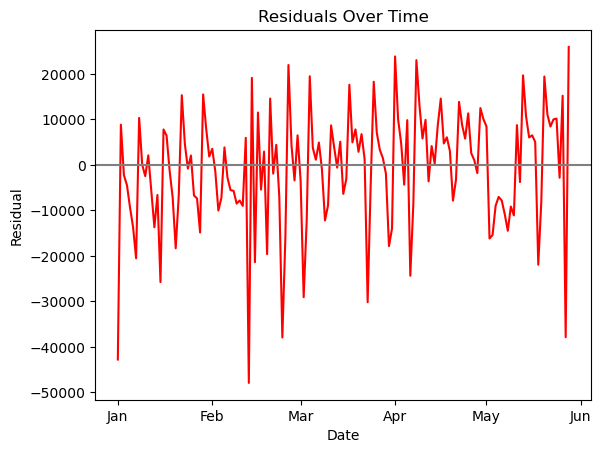

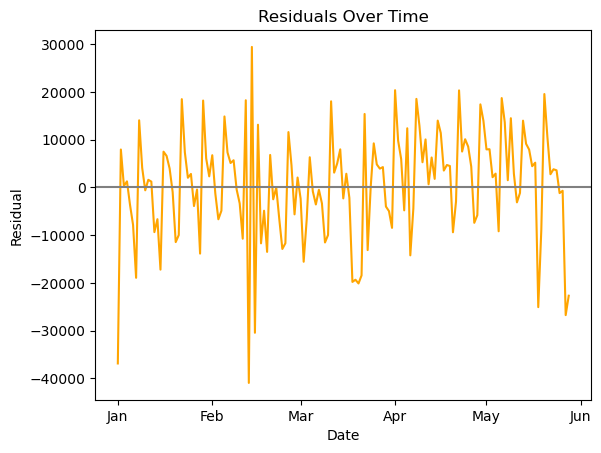

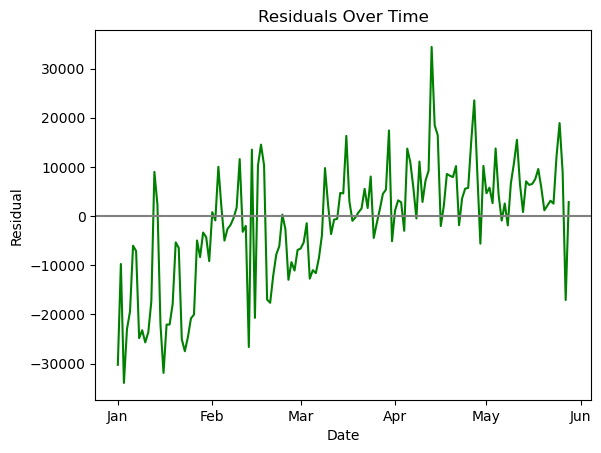

In [13]:
# ALC
# graph residuals over time for each train line
for line_color in ['red', 'orange', 'green']:
    residuals_df = x_test_with_resid[x_test_with_resid[f'line_{line_color}'] == True]
    ax = sns.lineplot(x = 'service_date', y = 'est_ridership', color = line_color, data = residuals_df)
    plt.axhline(y = 0, color = 'gray')
    plt.xlabel('Date')
    plt.ylabel('Residual')
    plt.title('Residuals Over Time')
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) 
    plt.show()

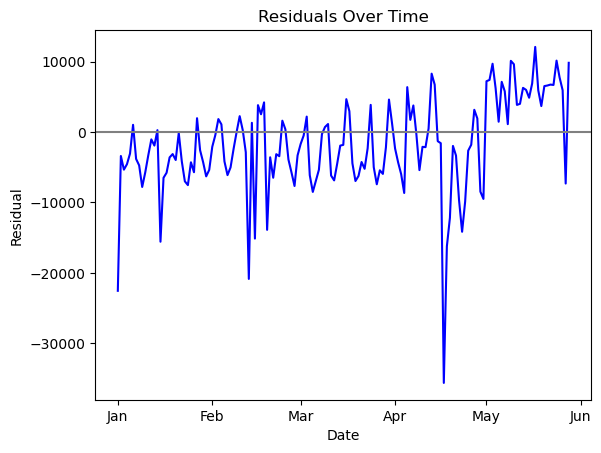

In [14]:
# ALC
# residuals for blue line
residuals_df = x_test_with_resid[(x_test_with_resid[f'line_green'] == False) &
                                (x_test_with_resid[f'line_orange'] == False) &
                                 (x_test_with_resid[f'line_red'] == False)]
ax = sns.lineplot(x = 'service_date', y = 'est_ridership', color = "blue", data = residuals_df)
plt.axhline(y = 0, color = 'gray')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.title('Residuals Over Time')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) 
plt.show()